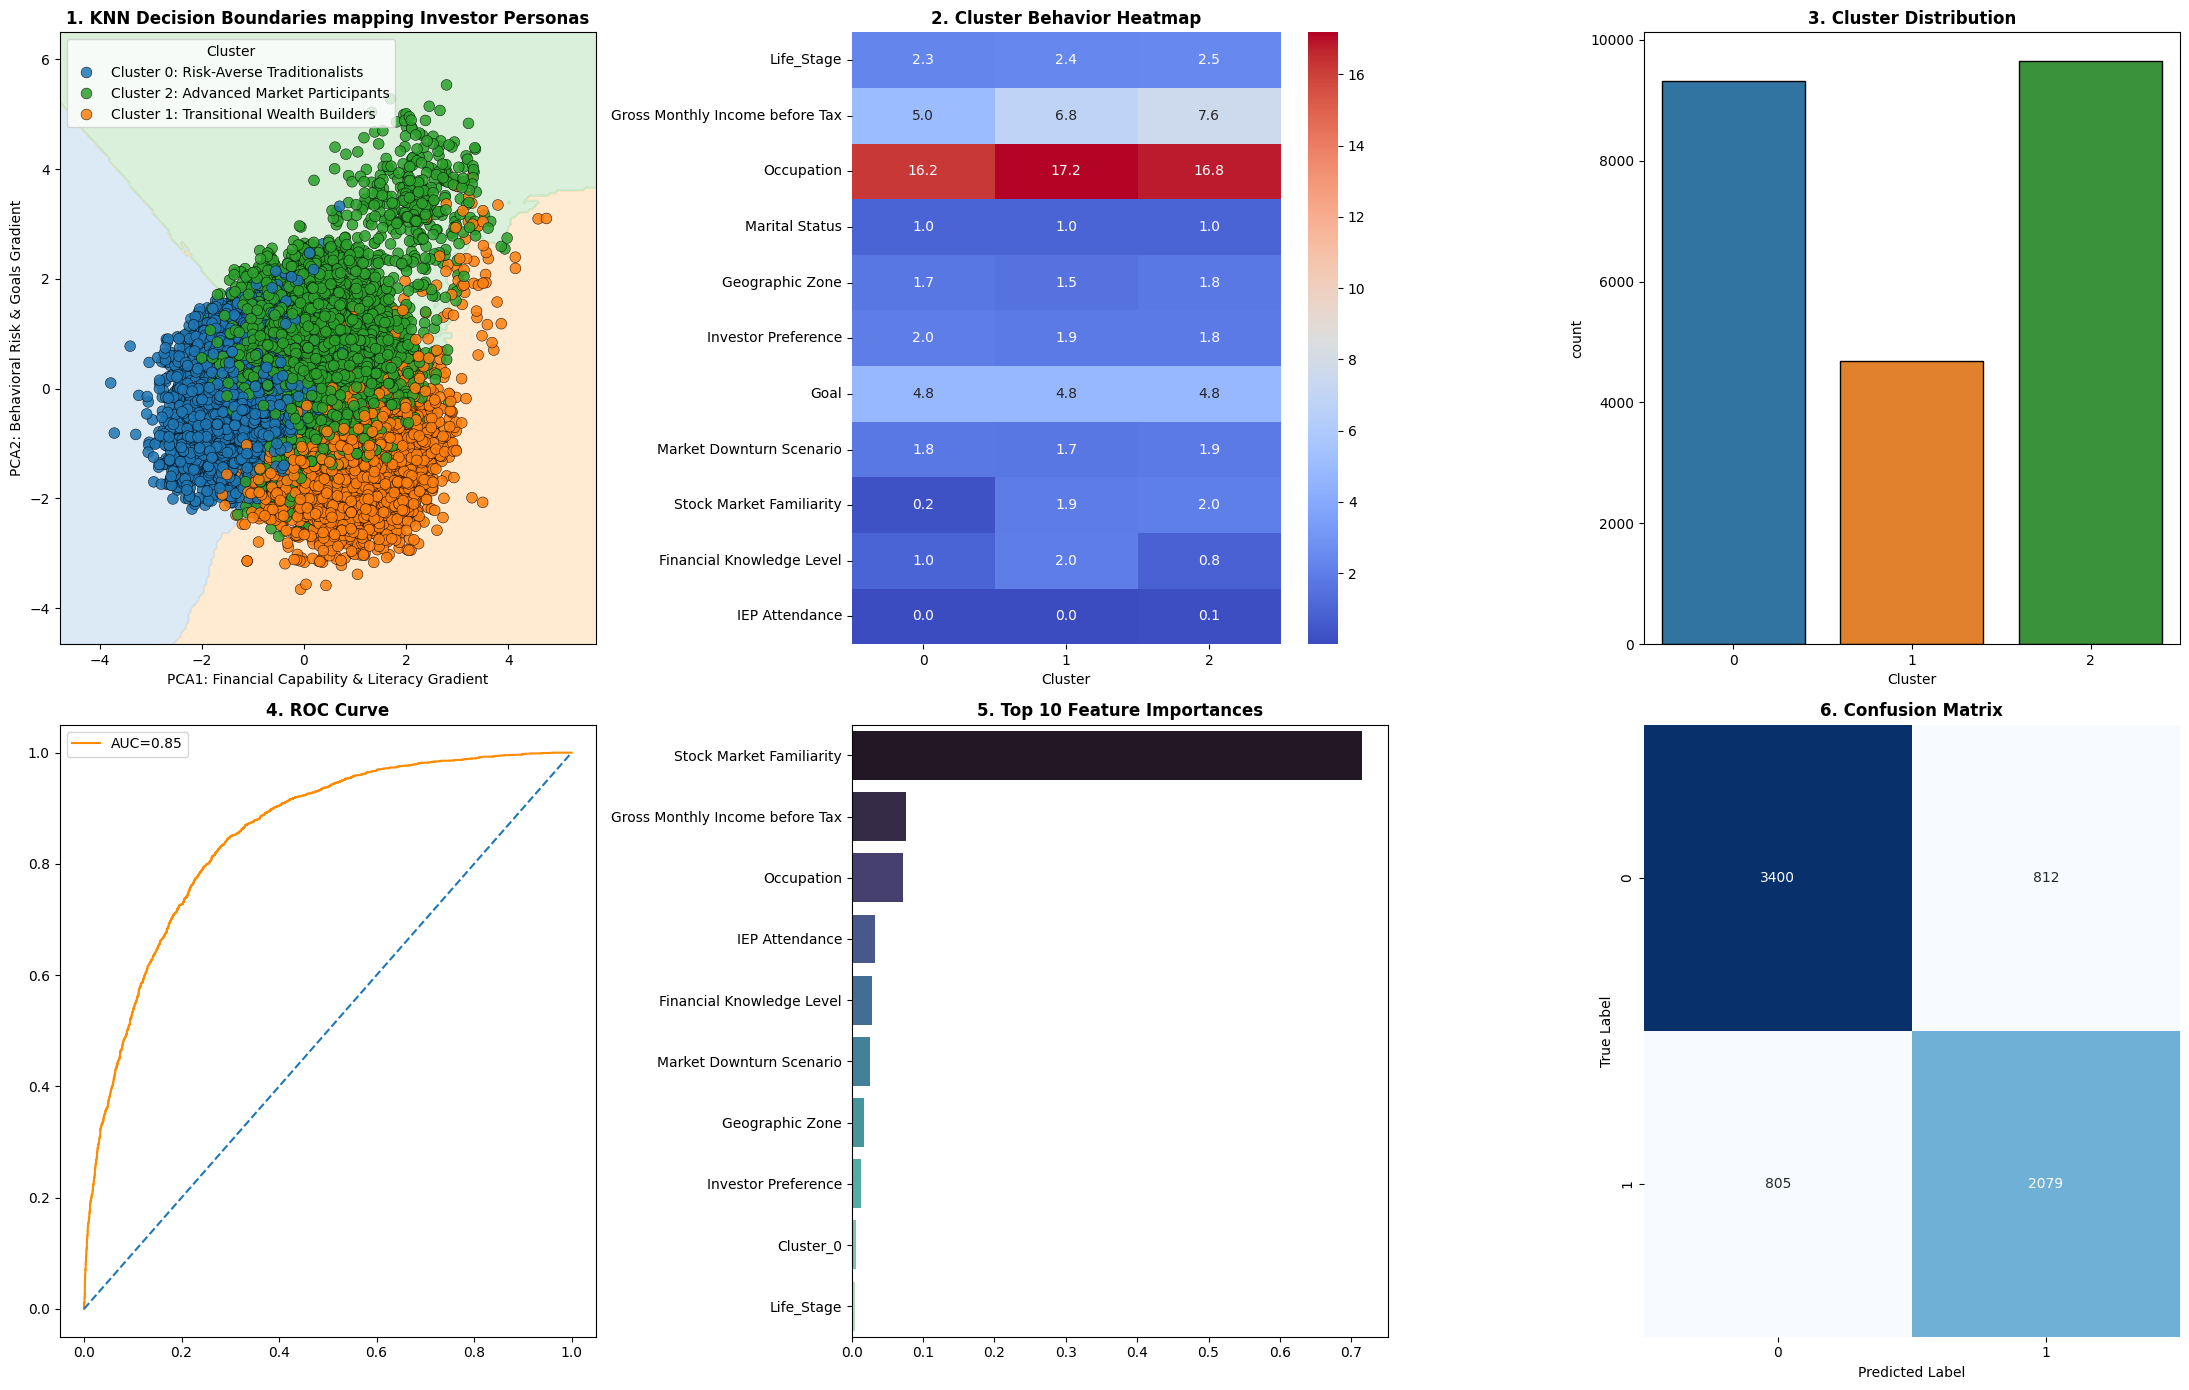

HTML(value="<h2 style='color:#2a75d3;'>Investment Predictor Engine</h2>")

Dropdown(description='Asset Class:', layout=Layout(width='400px'), options={'Futures & Options (F&O)': 'ADI_Da…

Button(button_style='success', description='Predict Adoption Probability', style=ButtonStyle())

Output()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings

warnings.filterwarnings('ignore')

# ==========================
# LOAD DATA
# ==========================

file_path = "/content/SEBI Investor Survey Data 2025.XLSX"
df_raw = pd.read_excel(file_path)

product_cols = [c for c in df_raw.columns if 'ADI_Dashboard' in c]
product_mapping = {col: str(df_raw.iloc[0][col]).split(':')[0].strip() for col in product_cols}

df_clean = df_raw.drop(0).reset_index(drop=True)

# ==========================
# FEATURE GROUPS
# ==========================

demographics = [
    'Life_Stage',
    'Gross Monthly Income before Tax',
    'Occupation',
    'Marital Status',
    'Geographic Zone'
]

inv_behavior = [
    'Investor Preference',
    'Goal',
    'Market Downturn Scenario'
]

literacy_media = [
    'Stock Market Familiarity',
    'Financial Knowledge Level',
    'IEP Attendance'
]

target_col = 'Investor Status'
features = demographics + inv_behavior + literacy_media

# ==========================
# DATA PREPARATION
# ==========================

X_full = df_clean[features].copy()

for col in X_full.columns:
    X_full[col].fillna(X_full[col].mode()[0], inplace=True)

encoders = {}

for col in X_full.columns:
    if X_full[col].dtype == 'object':
        le = LabelEncoder()
        X_full[col] = le.fit_transform(X_full[col].astype(str))
        encoders[col] = le

# ==========================
# FEATURE SCALING
# ==========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# ==========================
# TARGET VARIABLE
# ==========================

y_target = df_clean[target_col].fillna(df_clean[target_col].mode()[0])
y_target = y_target.apply(lambda x: 1 if str(x).strip().upper() == 'INVESTOR' else 0)

# ==========================
# KMEANS CLUSTERING
# ==========================

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ==========================
# PCA
# ==========================

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ==========================
# MODEL DATAFRAME
# ==========================

df_model = X_full.copy()
df_model['Cluster'] = clusters
df_model['PCA1'] = X_pca[:,0]
df_model['PCA2'] = X_pca[:,1]
df_model['Target'] = y_target

# ==========================
# SUPERVISED MODEL
# ==========================

cluster_dummies = pd.get_dummies(df_model['Cluster'], prefix='Cluster')
X_sup = pd.concat([X_full, cluster_dummies], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_sup, y_target, test_size=0.3, random_state=42
)

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)
y_prob = gb_model.predict_proba(X_test)[:,1]

# ==========================
# VISUALIZATION GRID
# ==========================

fig, axes = plt.subplots(2,3, figsize=(22,14))

# ==========================
# 1. KNN DECISION BOUNDARY
# ==========================

knn = KNeighborsClassifier(n_neighbors=15)
knn.fit(X_pca, clusters)

colors_light = ['#c6dcf0','#ffdeb3','#c2e6c2']
cmap_light = ListedColormap(colors_light)

cluster_mapping = {
0:'Cluster 0: Risk-Averse Traditionalists',
1:'Cluster 1: Transitional Wealth Builders',
2:'Cluster 2: Advanced Market Participants'
}

persona_labels = df_model['Cluster'].map(cluster_mapping)

palette_dict = {
'Cluster 0: Risk-Averse Traditionalists':'#1f77b4',
'Cluster 1: Transitional Wealth Builders':'#ff7f0e',
'Cluster 2: Advanced Market Participants':'#2ca02c'
}

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1
h=0.05

xx,yy=np.meshgrid(
np.arange(x_min,x_max,h),
np.arange(y_min,y_max,h)
)

Z=knn.predict(np.c_[xx.ravel(),yy.ravel()])
Z=Z.reshape(xx.shape)

axes[0,0].contourf(xx,yy,Z,cmap=cmap_light,alpha=0.6)

sns.scatterplot(
x=X_pca[:,0],
y=X_pca[:,1],
hue=persona_labels,
palette=palette_dict,
alpha=0.85,
s=60,
edgecolor='black',
linewidth=0.4,
ax=axes[0,0]
)

axes[0,0].set_title("1. KNN Decision Boundaries mapping Investor Personas",fontweight='bold')
axes[0,0].set_xlabel("PCA1: Financial Capability & Literacy Gradient")
axes[0,0].set_ylabel("PCA2: Behavioral Risk & Goals Gradient")

# ==========================
# 2. CLUSTER HEATMAP
# ==========================

cluster_means = df_model.groupby('Cluster')[features].mean()

sns.heatmap(
cluster_means.T,
annot=True,
cmap='coolwarm',
fmt=".1f",
ax=axes[0,1]
)

axes[0,1].set_title("2. Cluster Behavior Heatmap",fontweight='bold')

# ==========================
# 3. CLUSTER DISTRIBUTION
# ==========================

sns.countplot(
data=df_model,
x='Cluster',
palette=['#1f77b4','#ff7f0e','#2ca02c'],
ax=axes[0,2],
edgecolor='black'
)

axes[0,2].set_title("3. Cluster Distribution",fontweight='bold')

# ==========================
# 4. ROC CURVE
# ==========================

fpr,tpr,_=roc_curve(y_test,y_prob)

axes[1,0].plot(
fpr,
tpr,
color='darkorange',
label=f"AUC={auc(fpr,tpr):.2f}"
)

axes[1,0].plot([0,1],[0,1],'--')

axes[1,0].set_title("4. ROC Curve",fontweight='bold')
axes[1,0].legend()

# ==========================
# 5. FEATURE IMPORTANCE
# ==========================

importances=gb_model.feature_importances_
indices=np.argsort(importances)[::-1]

sns.barplot(
x=importances[indices][:10],
y=[X_sup.columns[i] for i in indices[:10]],
palette='mako',
ax=axes[1,1]
)

axes[1,1].set_title("5. Top 10 Feature Importances",fontweight='bold')

# ==========================
# 6. CONFUSION MATRIX
# ==========================

cm=confusion_matrix(y_test,y_pred)

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues',
ax=axes[1,2],
cbar=False
)

axes[1,2].set_title("6. Confusion Matrix",fontweight='bold')
axes[1,2].set_xlabel("Predicted Label")
axes[1,2].set_ylabel("True Label")

plt.tight_layout()
plt.show()

# ==========================
# INVESTMENT ADOPTION PROBABILITY PREDICTOR
# ==========================

valid_products = {name: col for col, name in product_mapping.items() if str(name).lower() != 'nan'}

asset_dropdown = widgets.Dropdown(
options=valid_products,
description='Asset Class:',
layout=widgets.Layout(width='400px')
)

feature_widgets = {
col: widgets.Dropdown(
options=sorted(df_clean[col].astype(str).unique()),
description=col,
layout=widgets.Layout(width='350px')
)
for col in features
}

left_col = widgets.VBox(list(feature_widgets.values())[:6])
right_col = widgets.VBox(list(feature_widgets.values())[6:])

profile_builder = widgets.HBox([left_col,right_col])

predict_btn = widgets.Button(
description='Predict Adoption Probability',
button_style='success'
)

output_area = widgets.Output()

def on_predict_clicked(b):

    with output_area:
        clear_output()

        y_target = df_clean[asset_dropdown.value].astype(str).str.contains(
            'Active|Dormant',
            case=False,
            na=False
        ).astype(int)

        rf = RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        )

        rf.fit(X_full,y_target)

        user_profile=[]

        for col in features:

            val=feature_widgets[col].value

            if col in encoders:
                user_profile.append(encoders[col].transform([str(val)])[0])
            else:
                user_profile.append(float(val))

        prob = rf.predict_proba([user_profile])[0][1]*100

        print(f"\nPredicted probability of adopting {asset_dropdown.label}: {prob:.2f}%")

predict_btn.on_click(on_predict_clicked)

display(
widgets.HTML("<h2 style='color:#2a75d3;'>Investment Predictor Engine</h2>"),
asset_dropdown,
profile_builder,
predict_btn,
output_area
)